In [1]:
import pandas as pd
import numpy as np
import xarray as xr

from matplotlib import pyplot as plt

import re
import glob 

import statsmodels.api as sm



In [2]:
ls ../74B6_ogsue009b

20250624_MQ_vs_T/ wv_74B6.csv


In [3]:
# MAIN_DIR = '../74B9_ogsuse010b/'
# DIN = MAIN_DIR + '20250612_MQ_vs_T/'
# DIN = MAIN_DIR + '20250617_MQ_vs_T/'
# DIN = MAIN_DIR + '20250623_S/'
# DIN = MAIN_DIR + '20250619_no3/'


MAIN_DIR = '../74B6_ogsue009b/'
DIN = MAIN_DIR + '20250624_MQ_vs_T/'


# MAIN_DIR = '../74BA_ogsuse008b/'
# DIN = MAIN_DIR + '20250625/'


# MAIN_DIR = '../745F_ogsuse005b/'
# DIN = MAIN_DIR + '20250626_MQ_vs_T/'


FN_CAL = DIN + 'DAT/CALIBRAT.DAT'

In [4]:
def rd_spectrum(spec):
    
    metadata = {}
    data_lines = []
    in_data_block = False
    
    for iline, line in enumerate(spec):
        
        line = line.strip()
        if not line:
            continue
            
        # Stop if reached [END] or another section
        if line.startswith("[") and line.endswith("]") and in_data_block:
            break

        # Detect numeric data start
        if line[0].isdigit() or line[0] == "-":
            in_data_block = True

        if in_data_block:
            parts = line.split()
            # Ensure all parts are numbers
            try:
                row = [float(p) for p in parts]
                data_lines.append(row)
            except ValueError:
                continue
        else:
            # Parse metadata key = value
            if "=" in line:
                key, value = line.split("=", 1)
                metadata[key.strip()] = value.strip()

    # Convert numeric data to numpy arrays
    data = np.array(data_lines)
    wavelengths = data[:, 0]
    intensity = data[:, 1]

    # Build xarray Dataset
    ds = xr.Dataset(
        data_vars={
            "intensity": (("wavelength",), intensity)
        },
        coords={
            "wavelength": wavelengths
        },
        attrs=metadata
    )

    return ds        
        
def rd_CAL(FN_CAL):

    flds = ['Averaging',
     'CalFactor',
     'FlashCount',
     'IntegrationTime',
     'PathLength',
     'Temperature',
     'lampReference[0]',
     'lampReference[1]',
     'tempRefDiode',
     'tempSpectrometer',
     'tempMainCPU']



    # first count how many spectra in this file
    with open(FN_CAL, "r", errors="ignore") as f:
        d = sum(line[:10].count("[Spectrum]") for line in f)
        print(d, ' spectra to read...')


    #### initialize xr.Dataset
    # create data_vars
    data_vars = {"I": (("wv", "n"), (np.empty((255,d))))}
    for f in flds:
        data_vars.update({f:(('n'), np.empty(d))})


    # create dataset    
    ds_all = xr.Dataset(

        data_vars = data_vars,

        coords={
                "wv": np.empty(255, dtype='float'),
                "n": np.empty(d)
        }
    )    

    #### then read
    with open(FN_CAL, "r", errors="ignore") as f:

        ispectrum = 0

        for iline, line in enumerate(f):

            if line[:10] == '[Spectrum]':
                spectrum = [line]
                # print(iline)
                # continue

            elif line[:19] == '[END] of [Spectrum]':

                # print('finished loading spectrum')

                ds = rd_spectrum(spectrum);

                # add ds to ds_all
                # if ispectrum == 0:
                #     ds_all.assign_coords({'wv': ds['wavelength'].values[1:]})
                #     print(ds_all.wv)

                ds_all['n'].values[ispectrum] = ispectrum
                ds_all['I'].values[:,ispectrum] = ds['intensity'].values[1:]


                for f in flds:
                    ds_all[f].values[ispectrum] = ds.attrs[f]

                # step into the next spectrum
                ispectrum += 1     
                # continue

                # break


            else:
                spectrum.append(line)


    ds_all = ds_all.assign_coords({
                    'wv': ds['wavelength'].values[1:],
                    'n': np.arange(0,ispectrum,1)
                })    
    
    return ds_all        

In [5]:
ds_all = rd_CAL(FN_CAL)

2216  spectra to read...


In [6]:
ds_all

<xarray.Dataset>
Dimensions:           (wv: 255, n: 2216)
Coordinates:
  * wv                (wv) float64 190.4 191.1 191.9 192.7 ... 390.9 391.7 392.5
  * n                 (n) int64 0 1 2 3 4 5 6 ... 2210 2211 2212 2213 2214 2215
Data variables:
    I                 (wv, n) float64 1.582e+04 1.595e+04 ... -2.54 -1.949
    Averaging         (n) float64 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
    CalFactor         (n) float64 1.601e+04 1.632e+04 ... 1.649e+04 1.66e+04
    FlashCount        (n) float64 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
    IntegrationTime   (n) float64 256.0 256.0 256.0 256.0 ... 256.0 256.0 256.0
    PathLength        (n) float64 10.0 10.0 10.0 10.0 ... 10.0 10.0 10.0 10.0
    Temperature       (n) float64 7.688 7.875 7.969 8.031 ... 30.12 30.12 30.12
    lampReference[0]  (n) float64 1.601e+04 1.632e+04 ... 1.649e+04 1.66e+04
    lampReference[1]  (n) float64 3.697e+03 3.709e+03 ... 3.723e+03 3.759e+03
    tempRefDiode      (n) float64 7.156 7.625 7.906 8.094 ... 30.44 30.44 30.44
    tempSpectrometer  (n) float64 7.688 7.875 7.969 8.031 ... 30.12 30.12 30.12
    tempMainCPU       (n) float64 7.812 8.219 8.469 8.656 ... 31.94 31.94 31.94

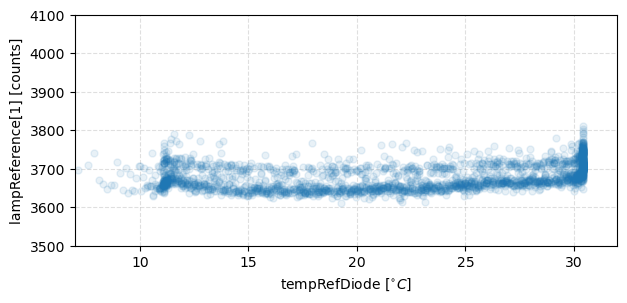

In [6]:
fig, ax = plt.subplots(1, figsize=(7,3))

ax.plot(ds_all['tempRefDiode'], ds_all['lampReference[1]'], 'o', ms=5, alpha=0.1)

ax.set_xlabel(r'tempRefDiode [$^{\circ}C$]')
ax.set_ylabel(r'lampReference[1] [counts]')

ax.grid(ls='--', alpha=0.4)
ax.set_xlim([7, 32])
ax.set_ylim([3500, 4100])

fnout = DIN + 'Results/lampRef1_vs_Tint.png'
fig.savefig(fnout, dpi=300)



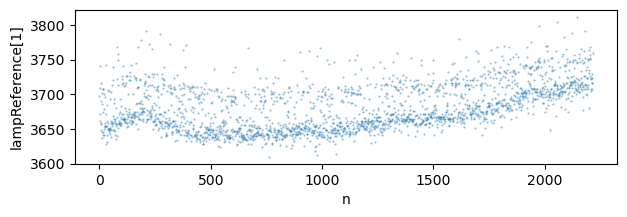

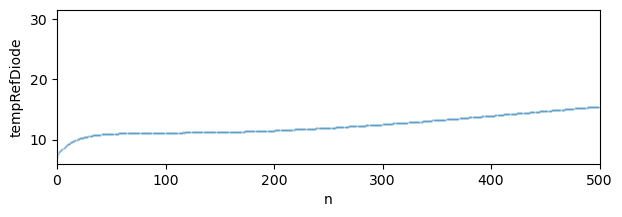

In [7]:
ds_all['lampReference[1]'].plot(lw=0, marker='.', ms=1, alpha=0.5,figsize=(7,2))
ds_all['tempRefDiode'].plot(lw=0, marker='.', ms=1, alpha=0.5,figsize=(7,2), xlim=[0, 500])

In [8]:
ds_all.tempRefDiode.shape

(2216,)

In [9]:
ds = ds_all.thin(n=10)

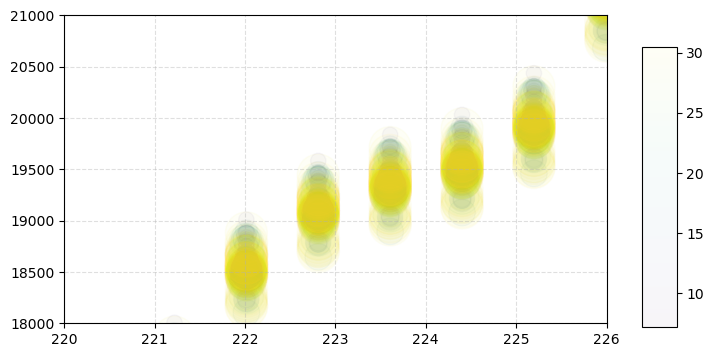

In [25]:
fig, ax = plt.subplots(1, figsize=[7,4])

ax.grid(ls='--', alpha=0.4)

hh = ax.scatter(ds.wv.values.reshape(-1,1) * np.ones([1,ds.I.shape[1]]), ds.I, 
           c=(ds.tempRefDiode.values.reshape(-1,1) * np.ones([1,ds.wv.shape[0]])).T, s=(ds.tempRefDiode.values.reshape(-1,1) * np.ones([1,ds.wv.shape[0]])).T**2, 
                alpha=0.04,
                
               );

ax.set_xlim([220, 226])
ax.set_ylim([18000, 21000])

cax = fig.add_axes([0.95, 0.1, 0.05, 0.7])


fig.colorbar(hh, cax=cax, orientation='vertical')



In [11]:
I0 = ds_all.I.values[:,50]

ds_all['Atot'] = ds_all['I'].copy(deep=True)

ds_all['Atot'].values = -np.log10( ds_all.I.values / (I0.reshape(-1,1) * np.ones([1,ds_all.I.shape[1]]) ) )

ds = ds_all.thin(n=10)

/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_3535/3704229502.py:5: RuntimeWarning: divide by zero encountered in log10
  ds_all['Atot'].values = -np.log10( ds_all.I.values / (I0.reshape(-1,1) * np.ones([1,ds_all.I.shape[1]]) ) )
/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_3535/3704229502.py:5: RuntimeWarning: invalid value encountered in log10
  ds_all['Atot'].values = -np.log10( ds_all.I.values / (I0.reshape(-1,1) * np.ones([1,ds_all.I.shape[1]]) ) )


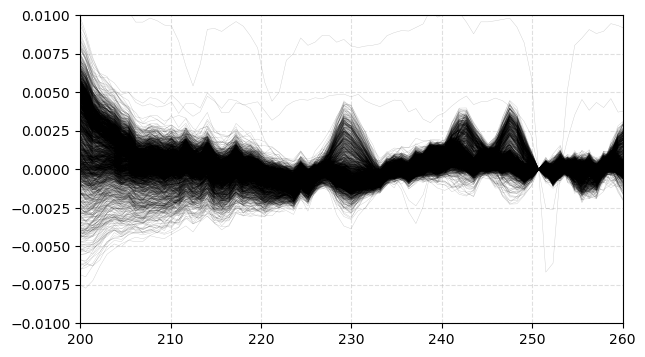

In [12]:
fig, ax = plt.subplots(1, figsize=[7,4])

ax.grid(ls='--', alpha=0.4)



# hh = ax.scatter(ds.wv.values.reshape(-1,1) * np.ones([1,ds.Atot.shape[1]]), ds.Atot, 
#            c=(ds.tempRefDiode.values.reshape(-1,1) * np.ones([1,ds.wv.shape[0]])).T, s=1, 
#                 alpha=0.4,
                
#                );
i250 = np.where(ds_all.wv>=250)[0][0]
irng = np.arange(0,2200,1)
ax.plot(ds_all.wv, ds_all.Atot.values[:,irng] - ds_all.Atot.values[i250,irng], 'k-', lw=0.3, alpha=0.2)


# cax = fig.add_axes([0.95, 0.1, 0.05, 0.7])

ax.set_xlim([200, 260])
# ax.set_ylim([-0.02, 0.02])
ax.set_ylim([-0.01, 0.01])

fig.colorbar(hh, cax=cax, orientation='vertical')
